# Process SlideRule ICESat-2 data 
Accessed in SlideRule_data_access.ipynb  
In this notebook: 
* add day of year, day of water year, and datetime column for the acquisition dates  
* sample WUS-SR at each ATL06-SR point for snow depth, SWE, and fSCA (and test techniques: nearest neighbor, linear, and cubic)
* calculate the difference between 'h_mean' and 3DEP elevation at each point, with the column named 'icesat2_3dep_dif' 
* also create columns for the offset between the 'icesat2_3dep_dif' column and reanalysis snow depth ('reanalysis_sd')
* create a mask for identify the 'snow covered' regions of the Sierra Nevada, where the average fSCA on 1 April of 1985 - 2021 is > 0.5

In [1]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rxr
import pickle
from astropy.time import Time
from pathlib import Path

In [2]:
sierras = gpd.read_file('../data/misc/sierra_simplified.geojson')

### Load ICESat-2 data downloaded over Sierra Nevada:

In [3]:
atl06sr_gdf = pickle.load(open(f'../data/icesat2/sierras_gdf_2018_2021_sa.pkl', 'rb'))
atl06sr_gdf

,segment_watermask,segment_snowcover,pflags,3dep.value,region,3dep.deriv.slope,gt,n_fit_photons,w_surface_window_final,3dep.fileid,...,cycle,photon_start,geometry,time,slope_count,slope,aspect,file,value,time_acq
time_ns,,,,,,,,,,,,,,,,,,,,,
2018-10-14 11:40:32.487777792,0.0,1.0,0,1519.017723,6,3.702048,50,28,3.0,158913789952,...,1,2730912,POINT (-119.96541 39.64595),2022-12-03 18:59:21,9,3.702048,71.460119,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1519.017727,2018-10-14 11:40:32.487777792
2018-10-14 11:40:32.490599168,0.0,1.0,0,1518.552710,6,3.227038,50,37,3.0,158913789952,...,1,2730940,POINT (-119.96543 39.64577),2022-12-03 18:59:21,9,3.227038,233.839977,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1518.552714,2018-10-14 11:40:32.490599168
2018-10-14 11:40:32.493418752,0.0,1.0,0,1518.741140,6,2.125614,50,44,3.0,158913789952,...,1,2730960,POINT (-119.96545 39.6456),2022-12-03 18:59:21,9,2.125614,78.941620,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1518.741144,2018-10-14 11:40:32.493418752
2018-10-14 11:40:32.496237568,0.0,1.0,0,1518.743413,6,1.243358,50,41,3.0,158913789952,...,1,2730989,POINT (-119.96548 39.64542),2022-12-03 18:59:21,9,1.027569,229.168357,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1518.894784,2018-10-14 11:40:32.496237568
2018-10-14 11:40:32.499053056,0.0,1.0,0,1518.892049,6,0.707748,50,32,3.0,158913789952,...,1,2731010,POINT (-119.9655 39.64524),2022-12-03 18:59:21,9,0.707748,129.684072,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1518.892053,2018-10-14 11:40:32.499053056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-30 07:56:05.208622336,0.0,1.0,0,284.338497,6,1.941521,20,34,3.0,94489280512,...,13,5778111,POINT (-118.90845 35.92973),2022-12-03 18:59:21,9,1.941521,305.870117,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,284.338555,2021-09-30 07:56:05.208622336
2021-09-30 07:56:05.211433728,0.0,1.0,0,283.677498,6,2.244505,20,27,3.0,94489280512,...,13,5778134,POINT (-118.90847 35.92955),2022-12-03 18:59:21,9,2.244505,293.216634,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,283.677556,2021-09-30 07:56:05.211433728
2021-09-30 07:56:05.214239488,0.0,1.0,0,282.900288,6,2.365801,20,26,3.0,94489280512,...,13,5778147,POINT (-118.9085 35.92938),2022-12-03 18:59:21,9,2.365801,283.413983,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,282.900346,2021-09-30 07:56:05.214239488


In [4]:
atl06sr_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### Clip to simplified polygon of the Sierra Nevada:

In [5]:
atl06sr_gdf = atl06sr_gdf.clip(sierras.to_crs(atl06sr_gdf.crs))
atl06sr_gdf = atl06sr_gdf.sort_values(by='time_acq',ascending=True)

### Load reanalysis data, which will be sampled at ATL06-SR points for snow depth, swe, and fsca:

In [6]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../analog_snowmapping/swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2018, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 31GB
Dimensions:      (time: 1461, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 12kB 2017-10-01 2017-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 10GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 10GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 10GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

### Create date columns for easier indexing:

In [7]:
import datetime

def day_of_year(date):
    # Check if it's a leap year
    leap_year = date.year % 4 == 0 and (date.year % 100 != 0 or date.year % 400 == 0)
    
    # Define days in each month, accounting for leap year
    days_in_month = [31, 29 if leap_year else 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    
    # Calculate day of the year
    day_count = sum(days_in_month[i] for i in range(date.month - 1)) + date.day
    
    return day_count

# Example usage
date = datetime.date(2024, 5, 9)
print("Day of the year:", day_of_year(date))

Day of the year: 130


In [8]:
#Add DOY and DOWY column
def add_dowy(df, col=None):
    print("Adding Day of Water Year (DOWY)")
    if col is None:
        df['doy'] = df.index.dayofyear
        df['decyear'] = Time(df.index).decimalyear
    else:
        df['doy'] = pd.to_datetime(df[col]).dt.dayofyear
        df['decyear'] = Time(pd.to_datetime(df[col])).decimalyear
    
    #df['dowy'] = (df['doy'].index - pd.DateOffset(months=9)).dayofyear
    # Sept 30 is doy 273
    df['dowy'] = df['doy'] - 273
    df.loc[df['dowy'] <= 0, 'dowy'] += 365

In [9]:
add_dowy(atl06sr_gdf)

Adding Day of Water Year (DOWY)


In [10]:
atl06sr_gdf['acqdate'] = atl06sr_gdf.index.date
atl06sr_gdf['acqdate_dt'] = pd.to_datetime(atl06sr_gdf['acqdate'])

### Sample the reanalysis data at each ATL06-SR data point:

In [11]:
atl06sr_gdf['reanalysis_swe'] = np.nan
atl06sr_gdf['reanalysis_sca'] = np.nan
atl06sr_gdf['reanalysis_sd'] = np.nan

# write an efficient for loop to loop through each date from each year in the atl06sr_gdf and extract the swe, sca, sd values from the swe_sca_ds dataset and add them to the atl06sr_gdf as new columns  
for year in range(2018, 2022):
    print(f"Processing year: {year}")
    year_mask = atl06sr_gdf.index.year == year
    for date in atl06sr_gdf.loc[year_mask].index.normalize().unique():
        print(f"  Processing date: {date.date()}")
        date_mask = atl06sr_gdf.index.normalize() == date
        latitudes = xr.DataArray(atl06sr_gdf.loc[year_mask & date_mask].to_crs('epsg:4326').geometry.y.values, dims="points")
        longitudes = xr.DataArray(atl06sr_gdf.loc[year_mask & date_mask].to_crs('epsg:4326').geometry.x.values, dims="points")
        
        swe_values = swe_sca_ds['SWE_Post'].sel(time=date).interp(
            y=latitudes,
            x=longitudes,
            method="linear"
        ).values
        
        sca_values = swe_sca_ds['SCA_Post'].sel(time=date).interp(
            y=latitudes,
            x=longitudes,
            method="linear"
        ).values
        
        sd_values = swe_sca_ds['SD_Post'].sel(time=date).interp(
            y=latitudes,
            x=longitudes,
            method="linear"
        ).values
        
        atl06sr_gdf.loc[year_mask & date_mask, 'reanalysis_swe'] = swe_values
        atl06sr_gdf.loc[year_mask & date_mask, 'reanalysis_sca'] = sca_values
        atl06sr_gdf.loc[year_mask & date_mask, 'reanalysis_sd'] = sd_values

Processing year: 2018
  Processing date: 2018-10-14
  Processing date: 2018-10-15
  Processing date: 2018-10-18
  Processing date: 2018-10-19
  Processing date: 2018-10-23
  Processing date: 2018-11-04
  Processing date: 2018-11-08
  Processing date: 2018-11-09
  Processing date: 2018-11-12
  Processing date: 2018-11-13
  Processing date: 2018-11-16
  Processing date: 2018-11-17
  Processing date: 2018-11-20
  Processing date: 2018-11-21
  Processing date: 2018-11-25
  Processing date: 2018-12-03
  Processing date: 2018-12-07
  Processing date: 2018-12-11
  Processing date: 2018-12-12
  Processing date: 2018-12-15
  Processing date: 2018-12-16
  Processing date: 2018-12-19
  Processing date: 2018-12-20
Processing year: 2019
  Processing date: 2019-01-01
  Processing date: 2019-01-05
  Processing date: 2019-01-06
  Processing date: 2019-01-09
  Processing date: 2019-01-10
  Processing date: 2019-01-13
  Processing date: 2019-01-14
  Processing date: 2019-01-18
  Processing date: 2019-01

### Use the 37 years of reanalysis data to identify regions that usually have snow cover on April 1st:

In [12]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../analog_snowmapping/swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

### Create mask as pixels with an average April 1 fSCA > 0.5:

In [13]:
swe_sca_ds_allyrs = swe_sca_ds_allyrs.rename({'y': 'lat', 'x': 'lon'})

In [14]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs.sel(time=( (swe_sca_ds_allyrs['time'].dt.month == 4) & (swe_sca_ds_allyrs['time'].dt.day == 1))).compute()

In [15]:
# 2. Compute mean April 1 fsca across years
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True).compute()

In [16]:
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1.SCA_Post > 0.5

In [17]:
mask_da = mask.astype(np.int32)

In [18]:
latitudes = xr.DataArray(atl06sr_gdf.to_crs('epsg:4326').geometry.y.values, dims="points")
longitudes = xr.DataArray(atl06sr_gdf.to_crs('epsg:4326').geometry.x.values, dims="points")

In [19]:
sampled_mask = mask_da.sel(lat=latitudes, lon=longitudes, method='nearest').values

In [20]:
atl06sr_gdf['mask'] = sampled_mask

In [21]:
atl06sr_gdf_masked = atl06sr_gdf.loc[(atl06sr_gdf['mask'] == 1)]

<Axes: >

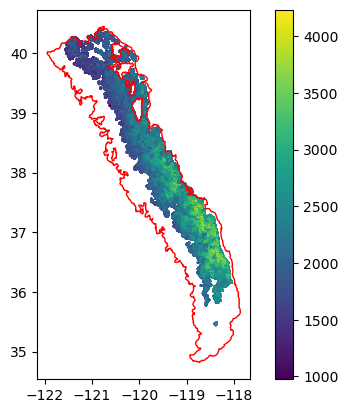

In [23]:
fig, ax = plt.subplots()
atl06sr_gdf_masked.plot(ax=ax, column='h_mean', cmap='viridis', markersize=1, legend=True)
sierras.boundary.plot(ax=ax, color='red', linewidth=1)

### Calculate the difference between ATL06-SR elevation and 3DEP elevations:

In [25]:
atl06sr_gdf_masked['icesat2_3dep_dif'] = atl06sr_gdf_masked['h_mean'] - atl06sr_gdf_masked['3dep.value']

In [ ]:
np.nanmedian(atl06sr_gdf_masked.loc[(atl06sr_gdf_masked['reanalysis_sca']==0) & (atl06sr_gdf_masked['3dep.deriv.slope']<20), 'icesat2_3dep_dif'])

np.float64(-0.016281316758522735)